In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('/content/student_dataset_1000.csv')

In [8]:
df.head()

,student_id,name,department,math,science,programming,attendance
0,1,Sumit Sharma,CS,76,66,50,83
1,2,Divya Singh,IT,79,76,76,98
2,3,Amit Verma,ECE,72,71,68,93
3,4,Karan Nair,IT,66,58,49,72
4,5,Tarun Singh,ECE,82,83,79,83


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   student_id   1000 non-null   int64 
 1   name         1000 non-null   object
 2   department   1000 non-null   object
 3   math         1000 non-null   int64 
 4   science      1000 non-null   int64 
 5   programming  1000 non-null   int64 
 6   attendance   1000 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 54.8+ KB


In [10]:
df.describe()

,student_id,math,science,programming,attendance
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,71.565000,71.591000,70.960000,84.600000
std,288.819436,14.323161,14.304347,15.042496,9.274482
min,1.000000,30.000000,30.000000,30.000000,51.000000
25%,250.750000,61.750000,62.000000,60.000000,78.000000
50%,500.500000,72.000000,71.500000,70.500000,85.000000
75%,750.250000,82.000000,81.000000,82.000000,91.000000
max,1000.000000,100.000000,100.000000,100.000000,100.000000


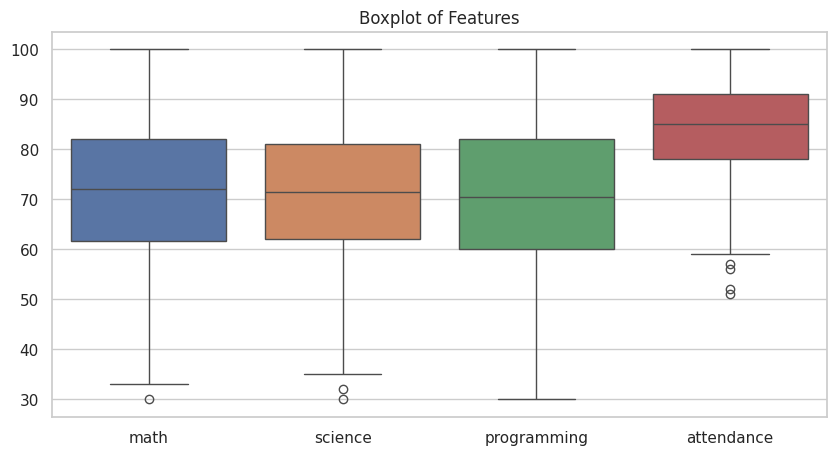

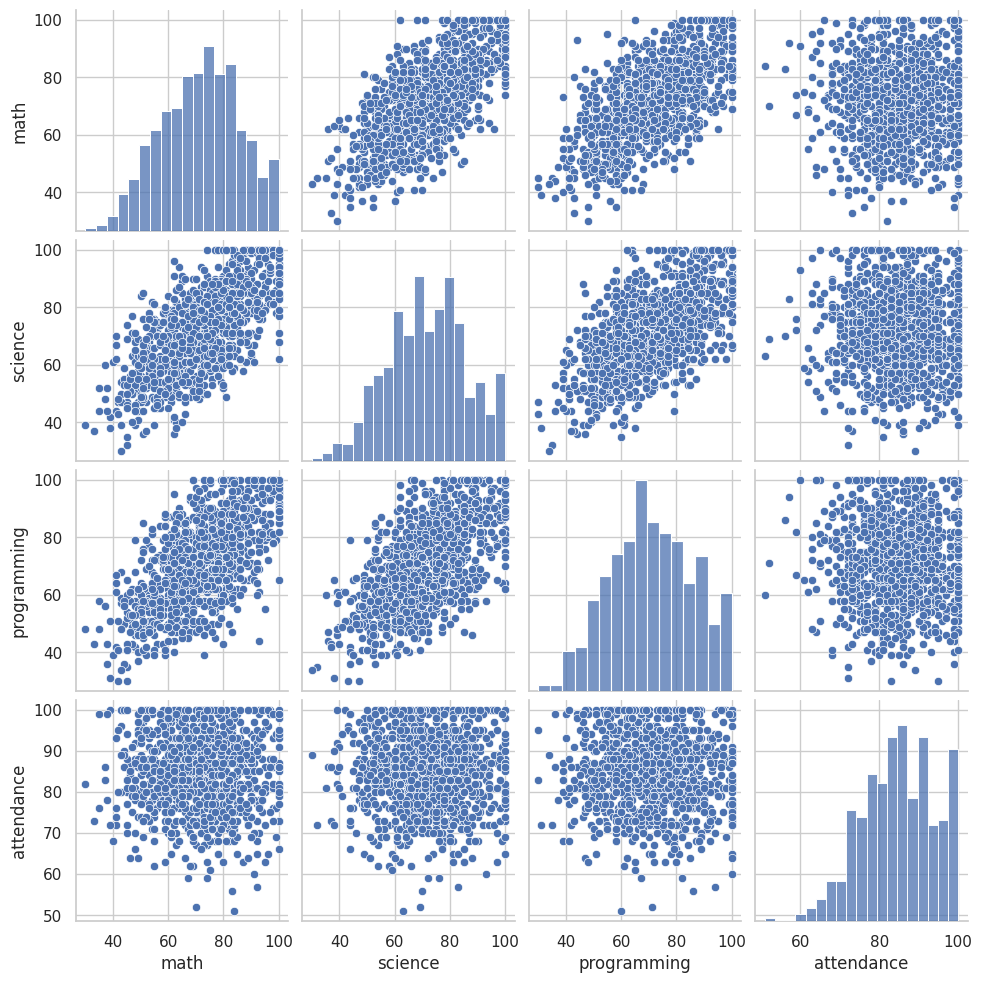

In [15]:


sns.set(style="whitegrid")
num_cols = ['math', 'science', 'programming', 'attendance']

# 1. BOXPLOT

plt.figure(figsize=(10,5))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot of Features")
plt.show()

# 2. PAIRPLOT

sns.pairplot(df[num_cols])
plt.show()


In [17]:
df['Average_Marks'] = (df['math']+df['science']+df['programming'])/3
df['Total_Marks'] = df['math']+df['science']+df['programming']

In [18]:
df.head()

,student_id,name,department,math,science,programming,attendance,Average_Marks,Total_Marks
0,1,Sumit Sharma,CS,76,66,50,83,64.000000,192
1,2,Divya Singh,IT,79,76,76,98,77.000000,231
2,3,Amit Verma,ECE,72,71,68,93,70.333333,211
3,4,Karan Nair,IT,66,58,49,72,57.666667,173
4,5,Tarun Singh,ECE,82,83,79,83,81.333333,244


## Identify Top Performing Student

In [19]:
top_student = df.loc[df['Total_Marks'].idxmax()]

print("Top Performing Student:")
print(top_student)

Top Performing Student:
student_id                176
name             Pallavi Nair
department              Civil
math                      100
science                   100
programming               100
attendance                 98
Average_Marks           100.0
Total_Marks               300
Name: 175, dtype: object


##Group Data by Department

In [22]:

dept_summary = df.groupby('department').agg({
    'math': 'mean',
    'science': 'mean',
    'programming': 'mean',
    'attendance': 'mean',
    'Total_Marks': 'mean',
    'student_id': 'count'
}).rename(columns={
    'math': 'avg_math',
    'science': 'avg_science',
    'programming': 'avg_programming',
    'attendance': 'avg_attendance',
    'Total_Marks': 'avg_total_marks',
    'student_id': 'total_students'
}).reset_index()

dept_summary

,department,avg_math,avg_science,avg_programming,avg_attendance,avg_total_marks,total_students
0,CS,71.622150,71.651466,71.452769,84.296417,214.726384,307
1,Civil,72.460526,74.171053,72.000000,84.526316,218.631579,76
2,ECE,71.541284,70.706422,70.399083,85.178899,212.646789,218
3,EEE,70.142857,70.017857,71.464286,84.107143,211.625000,56
4,IT,71.284644,71.730337,71.018727,85.048689,214.033708,267
5,ME,72.539474,71.973684,68.960526,83.026316,213.473684,76


## Relationship between attendance and marks

In [25]:
correlation = df[['attendance','math','science','programming','Total_Marks']].corr()

print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
             attendance      math   science  programming  Total_Marks
attendance     1.000000 -0.014611 -0.028978    -0.022975    -0.025453
math          -0.014611  1.000000  0.674521     0.635989     0.880629
science       -0.028978  0.674521  1.000000     0.613360     0.871531
programming   -0.022975  0.635989  0.613360     1.000000     0.864533
Total_Marks   -0.025453  0.880629  0.871531     0.864533     1.000000


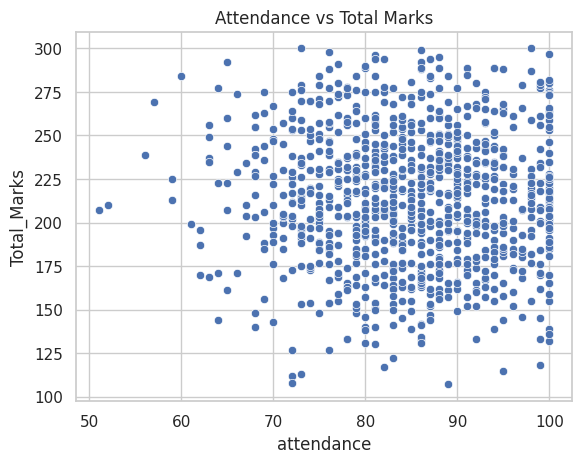

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot
sns.scatterplot(x='attendance', y='Total_Marks', data=df)
plt.title("Attendance vs Total Marks")
plt.show()

In [31]:

sns.set(style="whitegrid")

## department performance

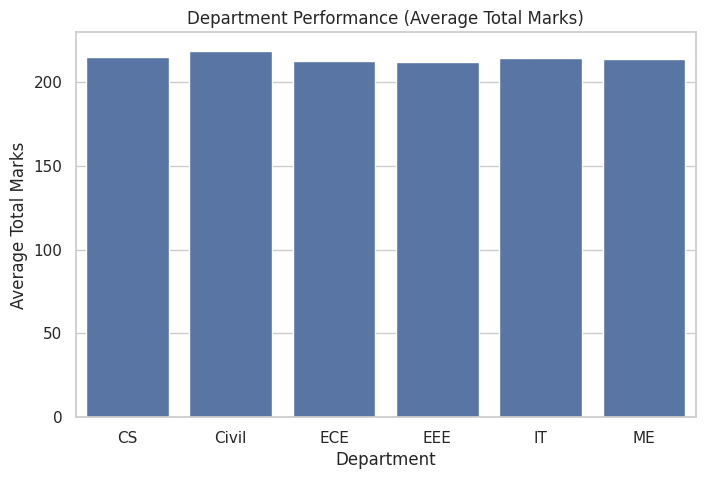

In [33]:
# Group by department
dept_perf = df.groupby('department')['Total_Marks'].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(x='department', y='Total_Marks', data=dept_perf)

plt.title("Department Performance (Average Total Marks)")
plt.xlabel("Department")
plt.ylabel("Average Total Marks")

plt.show()

## Attendance vs total marks

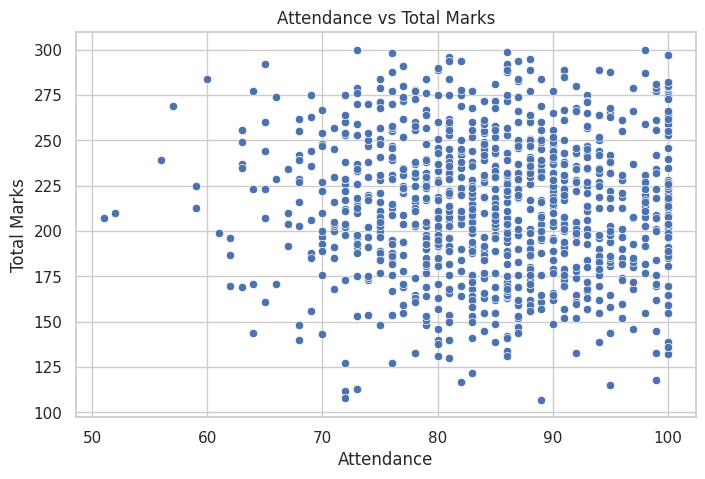

In [34]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='attendance', y='Total_Marks', data=df)

plt.title("Attendance vs Total Marks")
plt.xlabel("Attendance")
plt.ylabel("Total Marks")

plt.show()

## Heatmap

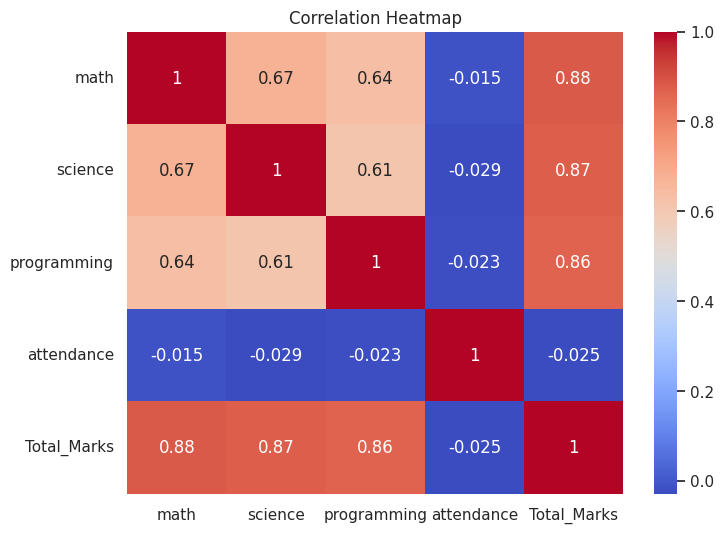

In [40]:
plt.figure(figsize=(8,6))

corr = df[['math','science','programming','attendance','Total_Marks']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()